
This notebook is an initial prototype of the statistical analysis engine for the BIOT 670I Vaccination Project. The current dataset is illustrative test data used to develop and validate the analysis workflow.  Planned analyses include baseline correlation, time-lagged associations, fixed-effects modeling, and uncertainty assessment.

In [1]:
# BIOT 670I Capstone - Vaccination Project
# Analysis Engine
# Kalkidan Perin



import pandas as pd
import numpy as np

from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf

print("Analysis environment ready.")

Analysis environment ready.


In [2]:

data = {
    "state": [
        "WA", "WA", "WA", "WA", "WA",
        "OR", "OR", "OR", "OR", "OR",
        "CA", "CA", "CA", "CA", "CA"
    ],

    "year": [
        2018, 2019, 2020, 2021, 2022,
        2018, 2019, 2020, 2021, 2022,
        2018, 2019, 2020, 2021, 2022
    ],

    "vaccination_coverage": [
        91.5, 91.0, 90.4, 89.8, 89.1,
        93.0, 92.7, 92.1, 91.6, 91.0,
        95.0, 94.8, 94.5, 94.2, 93.9
    ],

    "incidence_per_100k": [
        1.0, 1.2, 1.5, 2.0, 2.5,
        0.7, 0.8, 1.0, 1.3, 1.7,
        0.3, 0.4, 0.5, 0.6, 0.8
    ]
}

df = pd.DataFrame(data)

df

,state,year,vaccination_coverage,incidence_per_100k
0,WA,2018,91.5,1.0
1,WA,2019,91.0,1.2
2,WA,2020,90.4,1.5
3,WA,2021,89.8,2.0
4,WA,2022,89.1,2.5
5,OR,2018,93.0,0.7
6,OR,2019,92.7,0.8
7,OR,2020,92.1,1.0
8,OR,2021,91.6,1.3
9,OR,2022,91.0,1.7


In [3]:
# checking structure and quality of the dataset

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of unique states:")
print(df["state"].nunique())

print("\nYear range:")
print(df["year"].min(), "-", df["year"].max())

Dataset shape: (15, 4)

Column names:
['state', 'year', 'vaccination_coverage', 'incidence_per_100k']

Data types:
state                    object
year                      int64
vaccination_coverage    float64
incidence_per_100k      float64
dtype: object

Missing values:
state                   0
year                    0
vaccination_coverage    0
incidence_per_100k      0
dtype: int64

Number of unique states:
3

Year range:
2018 - 2022


 https://support.minitab.com/en-us/minitab/help-and-how-to/statistics/basic-statistics/supporting-topics/correlation-and-covariance/a-comparison-of-the-pearson-and-spearman-correlation-methods/$0

Pearson Correlation
Best use: Continuous variables with an approximately linear relationship.
Pattern type: Linear relationships.
Sensitivity: Can be strongly affected by outliers.
Statistical inference typically assumes conditions such as approximate bivariate normality.


Spearman Correlation
Best use: Ordinal data, ranked lists, or skewed continuous data.
Pattern type: Monotonic relationships (values consistently increase or decrease together).
Sensitivity: Highly robust against extreme outliers
Data shape: It does not require a normal distribution.


In [4]:
# Baseline correlation analysis
# Examines the association between vaccination coverage

pearson_r, pearson_p = pearsonr(
    df["vaccination_coverage"],
    df["incidence_per_100k"]
)


spearman_r, spearman_p = spearmanr(
    df["vaccination_coverage"],
    df["incidence_per_100k"]
)

print("BASELINE CORRELATION RESULTS")
print("----------------------------")

print(f"Pearson correlation:  r = {pearson_r:.3f}")
print(f"Pearson p-value:          {pearson_p:.4f}")

print(f"\nSpearman correlation: ρ = {spearman_r:.3f}")
print(f"Spearman p-value:          {spearman_p:.4f}")


BASELINE CORRELATION RESULTS
----------------------------
Pearson correlation:  r = -0.941
Pearson p-value:          0.0000

Spearman correlation: ρ = -0.972
Spearman p-value:          0.0000


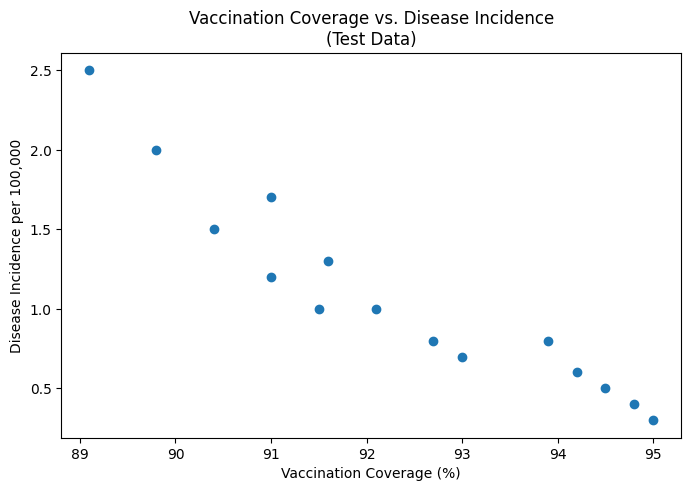

In [5]:
# Visualize the baseline relationship
# NOTE: Current data are illustrative test data only.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["vaccination_coverage"],
    df["incidence_per_100k"]
)

plt.xlabel("Vaccination Coverage (%)")
plt.ylabel("Disease Incidence per 100,000")
plt.title("Vaccination Coverage vs. Disease Incidence\n(Test Data)")

plt.show()

The final linked vaccination-coverage and disease-incidence dataset will replace the test data once it is available.

In [ ]:
#df = pd.read_csv("final_data.csv")